# TP1 ANALYSE UNIVARIEE

##Import des librairies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

## Chargement des données
Les données sont téléchargeables [ici](https://opendata.paris.fr/explore/dataset/les-arbres/export/?disjunctive.typeemplacement&disjunctive.arrondissement&disjunctive.libellefrancais&disjunctive.genre&disjunctive.espece&disjunctive.varieteoucultivar&disjunctive.stadedeveloppement&disjunctive.remarquable&basemap=jawg.dark&location=12,48.89046,2.34386) pour les arbres, et [ici](https://opendata.paris.fr/explore/dataset/quartier_paris/export/?disjunctive.c_ar) pour les quartiers. Ci-après, nous avons pris les arbres au format geojson, et les quartiers au format shapefile.

Les fichiers sont lus à l'aide de la fonction <code>gpd.read_file()</code>.


---


**N.B.** le nombre de lignes et les valeurs de données qui apparaissent dans ce support peuvent varier, les données étant mises à jour régulièrement sur le site opendata.paris.fr. Le chargement des données peut-être un peu long : le fichier des arbres contient 211402 lignes à la date de rédaction du support.

In [6]:
#lecture du fichier
arbres = gpd.read_file("les-arbres.geojson")
#Afficher le nom des colonnes
print(arbres.columns)
#Apercu des données
arbres.head()

Index(['idbase', 'typeemplacement', 'domanialite', 'arrondissement',
       'complementadresse', 'numero', 'adresse', 'idemplacement',
       'libellefrancais', 'genre', 'espece', 'varieteoucultivar',
       'circonferenceencm', 'hauteurenm', 'stadedeveloppement', 'remarquable',
       'geometry'],
      dtype='object')


,idbase,typeemplacement,domanialite,arrondissement,complementadresse,numero,adresse,idemplacement,libellefrancais,genre,espece,varieteoucultivar,circonferenceencm,hauteurenm,stadedeveloppement,remarquable,geometry
0,140175,Arbre,CIMETIERE,VAL-DE-MARNE,None,None,CIMETIERE DE THIAIS / AVENUE G / DIV 79,A11600079008,Tilleul,Tilia,x europaea,''Pallida'',20,5,None,NON,POINT (2.37771 48.75991)
1,209556,Arbre,Alignement,PARIS 16E ARRDT,None,None,AVENUE PRUDHON,000103003,Marronnier,Aesculus,x carnea,None,48,6,Jeune (arbre),NON,POINT (2.26987 48.85852)
2,230176,Arbre,Alignement,PARIS 13E ARRDT,None,None,BOULEVARD DE L HOPITAL,001806005,Micocoulier,Celtis,australis,None,45,5,Jeune (arbre),NON,POINT (2.35773 48.83504)
3,234439,Arbre,Alignement,PARIS 19E ARRDT,None,None,PLACE DES FETES,000102027,Tilleul,Tilia,cordata,None,100,16,Adulte,NON,POINT (2.39313 48.87658)
4,238396,Arbre,Alignement,PARIS 18E ARRDT,14,None,RUE RENE BINET,000206018,Marronnier,Aesculus,x carnea,''Briotii'',42,6,Jeune (arbre),NON,POINT (2.34179 48.89944)


Dans la librairie <code>geopandas</code>, les données sont sous la forme de <code>GeoDataframe</code>, qui sont des <code>Dataframe</code> de <code>pandas</code> où la géométrie des données, (ici des points 2D) est stockée dans une colonne <code>geometry</code> dédiée (au format de la librairie <code>shapely</code>).

Les individus sont identifiés par des index (e.g. <code>arbres.index</code>) et les variables par des colonnes (e.g. <code>arbres.columns</code>).

Plus de détails sur le format de données Pandas [ici](https://pandas.pydata.org/docs/user_guide/10min.html).

In [7]:
#lecture du fichier
quartier = gpd.read_file("quartier_paris.shp")
#On met comme identifiant du dataframe le numéro du quartier
quartier = quartier.set_index("n_sq_qu")
quartier.head()

,c_qu,c_quinsee,l_qu,c_ar,n_sq_ar,perimetre,surface,geometry
n_sq_qu,,,,,,,,
750000008.0,8.0,7510204.0,Bonne-Nouvelle,2.0,750000002.0,2233.976030,281448.206577,"POLYGON ((2.35152 48.86443, 2.35095 48.86341, ..."
750000010.0,10.0,7510302.0,Enfants-Rouges,3.0,750000003.0,2139.625388,271750.323937,"POLYGON ((2.3671 48.86163, 2.36727 48.86095, 2..."
750000013.0,13.0,7510401.0,Saint-Merri,4.0,750000004.0,2346.004687,313040.396550,"POLYGON ((2.35262 48.85491, 2.35249 48.85467, ..."
750000014.0,14.0,7510402.0,Saint-Gervais,4.0,750000004.0,2678.340923,422028.171324,"POLYGON ((2.36376 48.85568, 2.36294 48.85456, ..."
750000018.0,18.0,7510502.0,Jardin-des-Plantes,5.0,750000005.0,4052.729521,798389.398463,"POLYGON ((2.36456 48.84366, 2.3645 48.84358, 2..."


##Projeter et afficher les données

La projection se fait avec la méthode <code>to_crs()</code>. Le résultat n'est pas en place : il faut stocker dans une variable python le geodataframe reprojeté.

In [8]:
arbres = arbres.to_crs(epsg=2154)
quartier = quartier.to_crs(epsg=2154)

La méthode ```plot``` sert pour la visualisation des données, soit de manière géographique (```kind="geo"```), soit pour d'autres méthodes de visualisation héritée de pandas (e.g. histogrammes, boxplots...).



<Axes: >

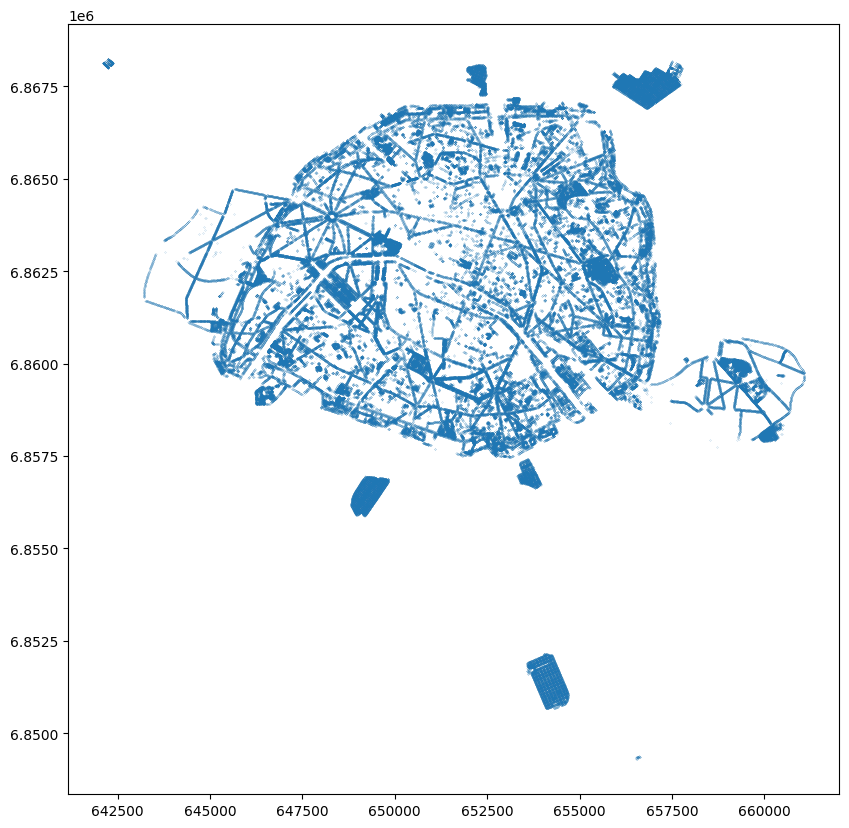

In [9]:
arbres.plot(figsize=(10, 10), markersize=0.01)#par défaut geopandas affiche la carte (kind="geo")

Il est possible de coloriser en fonction d'une variable qualitative ou quantitative en indiquant sa colonne.

Text(0.5, 1.0, 'arrondissement')

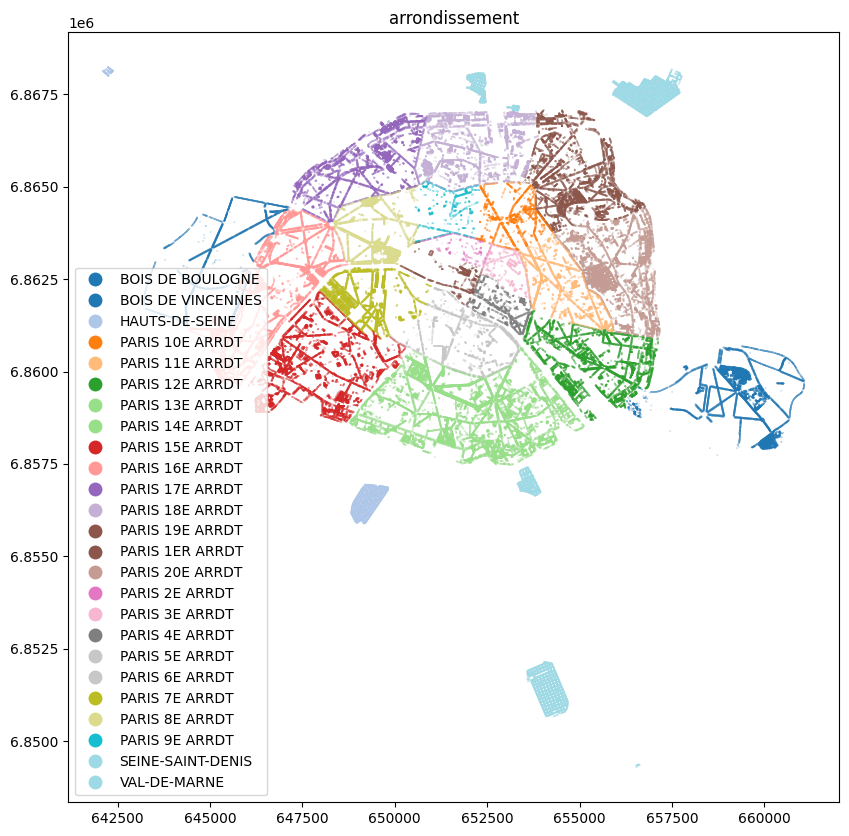

In [10]:
arbres.plot(figsize=(10, 10), markersize=0.01, column="arrondissement", legend=True, cmap="tab20").set_title("arrondissement")

Text(0.5, 1.0, 'hauteur des arbres')

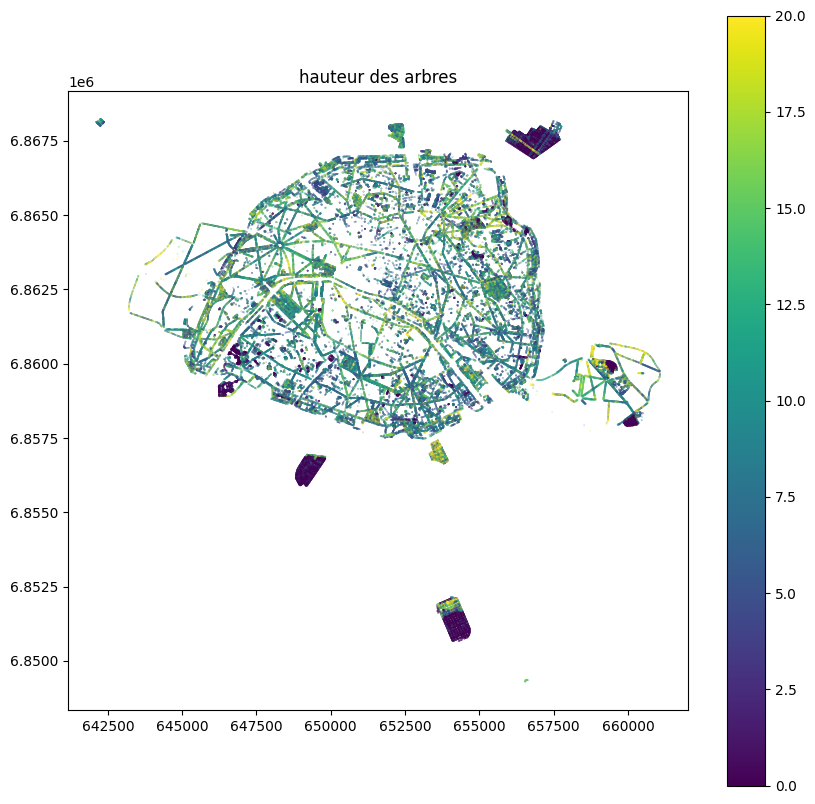

In [11]:
arbres.plot(figsize=(10, 10), markersize=0.01, column="hauteurenm", legend=True, cmap="viridis", vmax=20).set_title("hauteur des arbres")

# 1   Distribution statistique des arbres

##1.1 Calculer le nombre d'arbres par quartier

**Réaliser une jointure spatiale**

On réalise une jointure (spatiale) entre <code>quartier</code> et <code>arbres</code>, pour inclure les informations des arbres aux quartiers à l’aide du prédicat spatial "contains".

In [12]:
join = quartier.sjoin(
    arbres, how="left", predicate="contains"
    )

In [13]:
print(len(join))
join.head()

185151


,c_qu,c_quinsee,l_qu,c_ar,n_sq_ar,perimetre,surface,geometry,index_right,idbase,...,adresse,idemplacement,libellefrancais,genre,espece,varieteoucultivar,circonferenceencm,hauteurenm,stadedeveloppement,remarquable
n_sq_qu,,,,,,,,,,,,,,,,,,,,,
750000008.0,8.0,7510204.0,Bonne-Nouvelle,2.0,750000002.0,2233.97603,281448.206577,"POLYGON ((652426.165 6862905.834, 652383.463 6...",92706,229769,...,RUE DE TURBIGO,000501001,Chêne,Quercus,rubra,None,30,5,Jeune (arbre),NON
750000008.0,8.0,7510204.0,Bonne-Nouvelle,2.0,750000002.0,2233.97603,281448.206577,"POLYGON ((652426.165 6862905.834, 652383.463 6...",19676,229823,...,RUE DE TURBIGO,000501002,Chêne,Quercus,rubra,None,55,10,Adulte,NON
750000008.0,8.0,7510204.0,Bonne-Nouvelle,2.0,750000002.0,2233.97603,281448.206577,"POLYGON ((652426.165 6862905.834, 652383.463 6...",40943,229824,...,RUE DE TURBIGO,000501003,Chêne,Quercus,rubra,None,75,10,Adulte,NON
750000008.0,8.0,7510204.0,Bonne-Nouvelle,2.0,750000002.0,2233.97603,281448.206577,"POLYGON ((652426.165 6862905.834, 652383.463 6...",47543,229825,...,RUE DE TURBIGO,000501004,Chêne,Quercus,rubra,None,20,5,None,NON
750000008.0,8.0,7510204.0,Bonne-Nouvelle,2.0,750000002.0,2233.97603,281448.206577,"POLYGON ((652426.165 6862905.834, 652383.463 6...",109556,189185,...,ECOLE MATERNELLE / 12 RUE DUSSOUBS,056801004,Tilleul,Tilia,x euchlora,None,75,12,Adulte,NON


On obtient un dataframe qui contient les informations de chaque arbre et du quartier dans lequel il se trouve.
On peut ensuite calculer le nombre d'arbre par quartiers.

**Solution 1 : on regroupe la jointure par index des quartiers, et on compte le nombre d'arbre**

In [14]:
grouped = join.groupby("n_sq_qu")
nb_arbres_par_quartiers = grouped["idbase"].aggregate("count")

**Solution 2 : on calcule le nombre de valeurs uniques de quartiers**

In [15]:
 nb_arbres_par_quartiers = join.index.value_counts()

Dans les 2 cas l'index de <code>nb_arbres_par_quartiers</code> est le même que celui de <code>quartier</code>, on peut donc simplement ajouter une nouvelle variable <code>nb_arbres</code> au dataframe.



In [16]:
quartier["nb_arbres"] = nb_arbres_par_quartiers

## 1.2 Calculer la densité d'arbres par quartier
Il suffit ici de diviser le nombre d'arbres par quartier par la surface du quartier. Celle-ci peut s'obtenir grâce à `dataframe.area`. Il faut néanmoins faire attention à avoir bien projeter les données avant de calculer la surface.

In [17]:
#Attention, vérifier d'avoir projeté les données avant de calculer la surface
quartier["dens_arbres"] = quartier["nb_arbres"] / quartier.area

## 1.3 Comparaison des variables nombre et densité

Calculons tout d'abord la moyenne et l'écart-type des deux variables.

In [18]:
print(f"nombre moyen d'arbres par quartier : {quartier['nb_arbres'].mean():.2f} arbres")
print(f"écart-type du nombre d'arbres par quartier : {quartier['nb_arbres'].std():.2f} arbres")

print(f"Densité moyenne par quartier : {quartier['dens_arbres'].mean():.2e} arbres par m²")
print(f"écart-type de densité par quartier : {quartier['dens_arbres'].std():.2e} arbres par m²")

nombre moyen d'arbres par quartier : 2314.39 arbres
écart-type du nombre d'arbres par quartier : 2284.97 arbres
Densité moyenne par quartier : 1.60e-03 arbres par m²
écart-type de densité par quartier : 8.10e-04 arbres par m²


Histogrammes :

<Axes: title={'center': "Densité d'arbres par quartier"}, xlabel="densité d'arbres", ylabel='nombre de quartiers'>

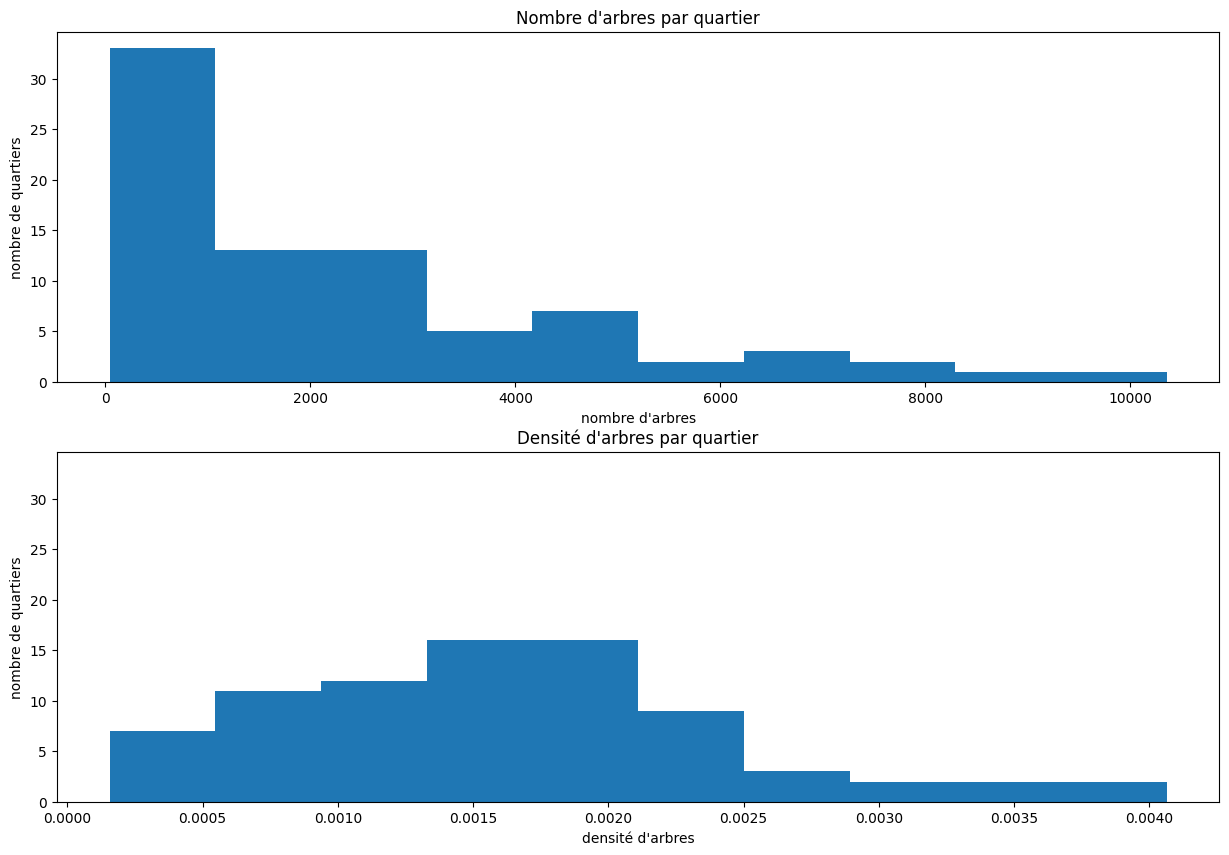

In [19]:
plt.figure(figsize=(15, 10))
ax1 = plt.subplot(2, 1, 1)
quartier["nb_arbres"].plot(ax=ax1, kind="hist", title="Nombre d'arbres par quartier", xlabel="nombre d'arbres", ylabel="nombre de quartiers")
ax2 = plt.subplot(2, 1, 2, sharey=ax1)
(quartier["dens_arbres"]).plot(ax=ax2, kind="hist", title="Densité d'arbres par quartier", xlabel="densité d'arbres", ylabel="nombre de quartiers")

Indicateurs de forme :

In [20]:
print(f"kurtosis du nombre d'arbres par quartier : {quartier['nb_arbres'].kurtosis():.2e} arbres")
print(f"skewness du nombre d'arbres par quartier : {quartier['nb_arbres'].skew():.2e} arbres")

print(f"kurtosis de la densité par quartier : {quartier['dens_arbres'].kurtosis():.2e} arbres par m²")
print(f"skewness de la densité par quartier : {quartier['dens_arbres'].skew():.2e} arbres par m²")

kurtosis du nombre d'arbres par quartier : 1.86e+00 arbres
skewness du nombre d'arbres par quartier : 1.44e+00 arbres
kurtosis de la densité par quartier : 5.85e-01 arbres par m²
skewness de la densité par quartier : 7.15e-01 arbres par m²


#2 Distribution spatiale des arbres
##2.1 Cartes simples
###2.1.1 Les 6 genres les plus fréquents

On peut compter le nombre d'apparition de chaque genre avec la méthode `value_counts`.

In [21]:
count_by_genre = arbres.value_counts("libellefrancais")
count_by_genre.head(6)

,count
libellefrancais,
Platane,42817
Marronnier,24904
Tilleul,22310
Erable,19811
Sophora,11558
Chêne,5031


Il suffit ensuite de filtrer les arbres qui appartiennent à un de ces genres, en utilisant la méthode `isin`.

Text(0.5, 1.0, '6 genres les plus fréquents')

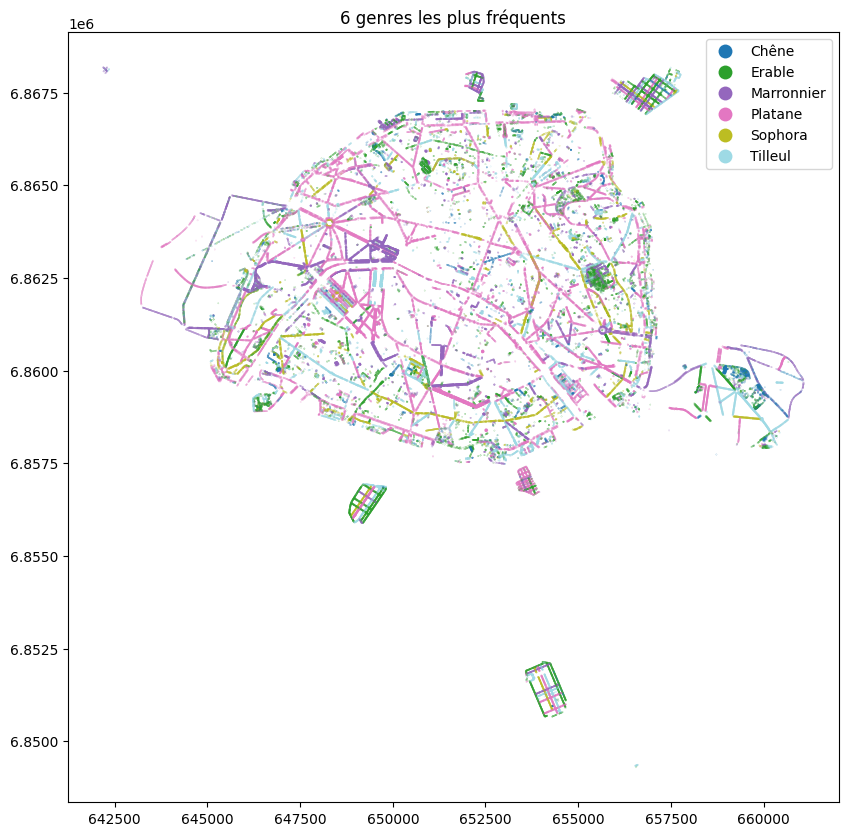

In [22]:
arbres_filtres = arbres[arbres["libellefrancais"].isin(count_by_genre.head(6).index)]


arbres_filtres.plot(figsize=(10, 10), markersize=0.01, column="libellefrancais", legend=True, cmap="tab20").set_title("6 genres les plus fréquents")

### 2.1.2 Carte de la dominialité

Text(0.5, 1.0, 'domanialite')

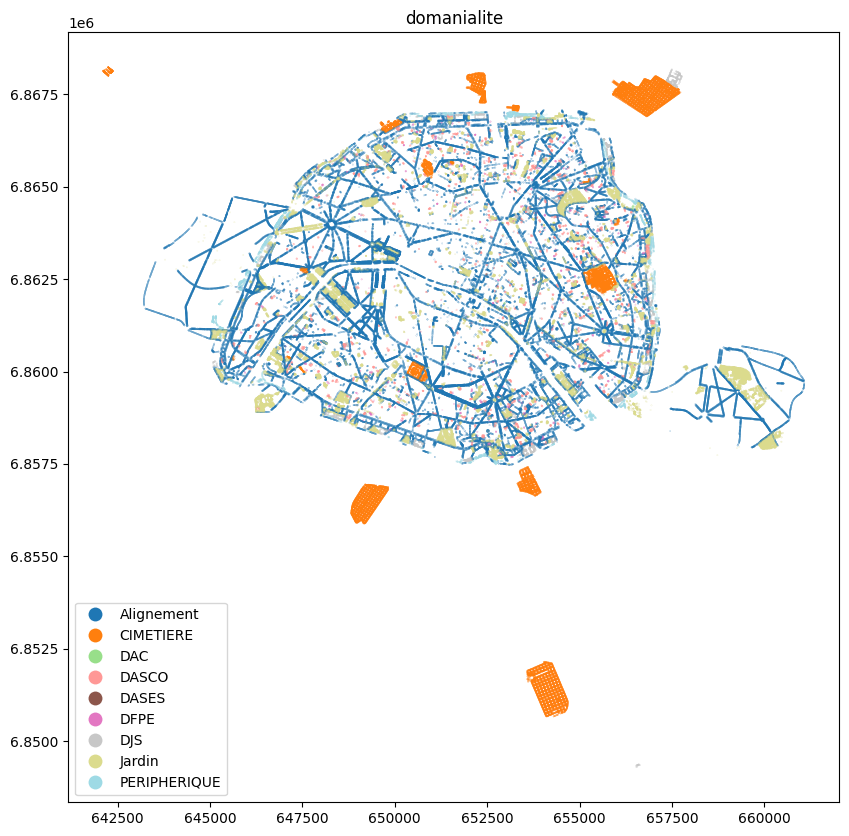

In [23]:
arbres.plot(figsize=(10, 10), markersize=0.01, column="domanialite", legend=True, cmap="tab20").set_title("domanialite")

##2.2 Cartographie du nombre d'arbres
###2.2.1 Carte choroplèthe du nombre d'arbres par quartier

Text(0.5, 1.0, "Nombre d'arbres par quartier")

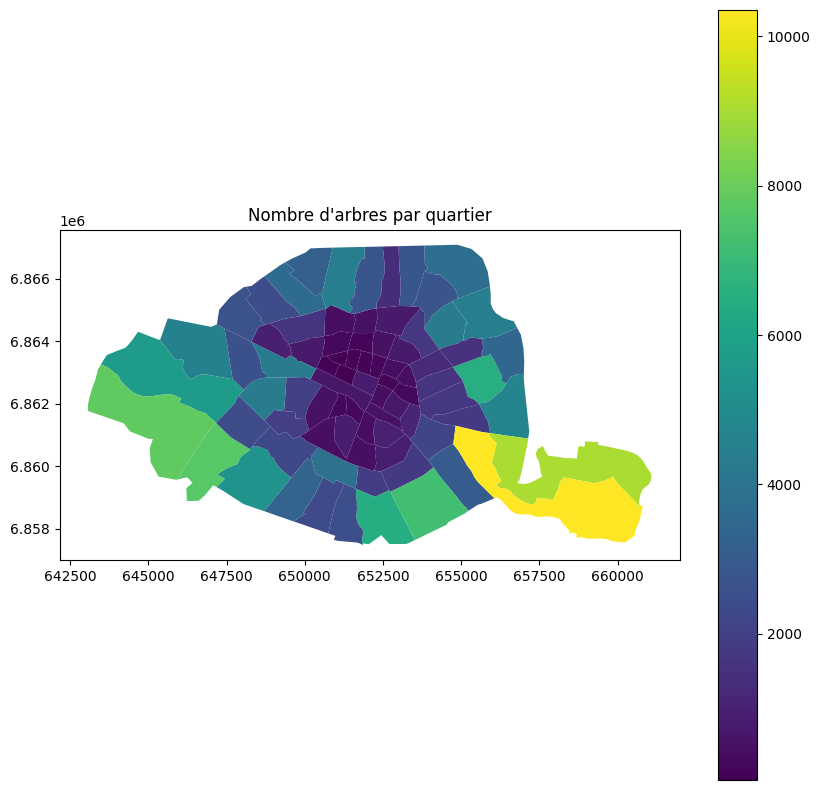

In [24]:
quartier.plot(figsize=(10, 10), column='nb_arbres', legend=True).set_title("Nombre d'arbres par quartier")

Représentation sémiologiquement discutable

### 2.2.2 Carte avec symboles proportionnels
Ce type de carte n'est pas directement réalisable avec `geopandas`. On va donc utiliser la fonction `plt.scatter`, avec en entrée la position des centres x et y des quartiers et la taille des marqueurs = nombre d'arbres * un facteur multiplicatif.

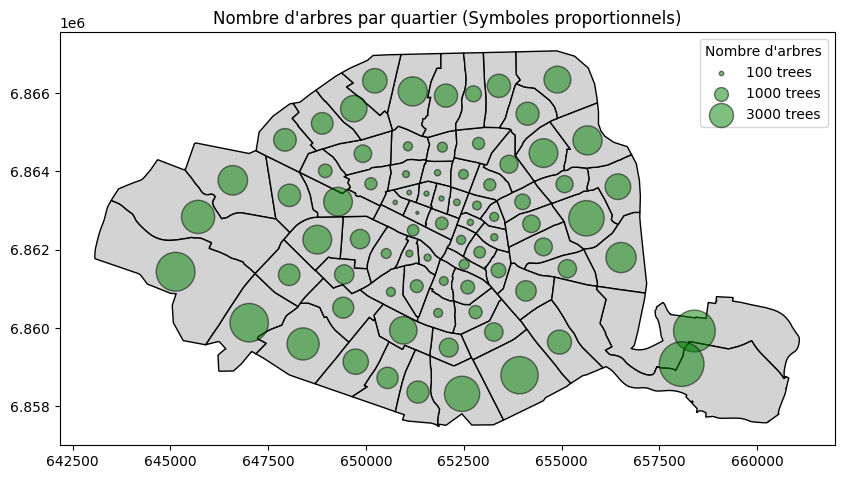

In [33]:
# Afficher les contours des quartiers
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
quartier.plot(ax=ax, color='lightgray', edgecolor='black')

# Calcul de la taille des marqueurs
marker_size_multiplier = 0.1
marker_sizes = quartier["nb_arbres"] * marker_size_multiplier

plt.scatter(quartier.geometry.centroid.x, quartier.geometry.centroid.y, s=marker_sizes, marker='o', color='green', alpha = 0.5, edgecolor='black')

plt.title("Nombre d'arbres par quartier (Symboles proportionnels)")

#Creer une légende : On donne un label à des scatter vides
for s in [100, 1000, 3000]:
    plt.scatter([], [], s=s*marker_size_multiplier, c='green', alpha=0.5, edgecolor='black', label=f'{int(s)} arbres')
plt.legend(title="Nombre d'arbres")

plt.show()

###2.2.3 Carte de chaleur du nombre d'arbres sur une grille raster

Pour réaliser une sorte de raster, nous allons créer une grille qui couvre la zone d’étude, et projeter les points du semis (le dataframe arbres_intramuros) dans les cellules créées (c’est également une façon d’approcher une carte de densité 2D de façon discrète)

Afin de ne pas faire une grille qui couvre la boîte englobante de la zone d’étude, mais que la grille ne couvre que les géométries de chaque quartier, on réalise une intersection entre la grille raster et l’enveloppe des quartiers.

<Axes: >

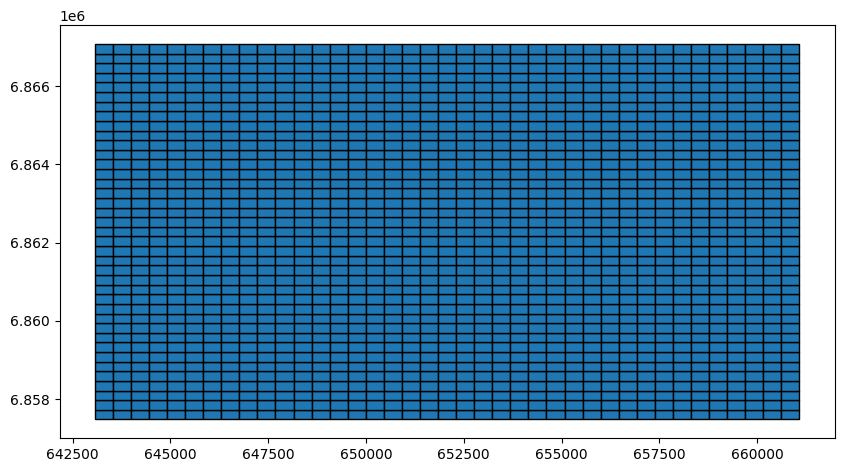

In [63]:
from shapely.geometry import Polygon
xmin, ymin, xmax, ymax = quartier.total_bounds

size = 40

cols = list(np.linspace(xmin, xmax, size))
rows = list(np.linspace(ymin, ymax, size))
wide = cols[1]-cols[0]
length = rows[1]-rows[0]


polygons = []
for x in cols[:-1]:
    for y in rows[:-1]:
        polygons.append(Polygon([(x,y), (x+wide, y), (x+wide, y+length), (x, y+length)]))

grid = gpd.GeoDataFrame({'geometry':polygons}).set_crs("EPSG:2154")
grid.plot(figsize=(10, 10), edgecolor='black')

On dissout la géométrie des quartiers.

<Axes: >

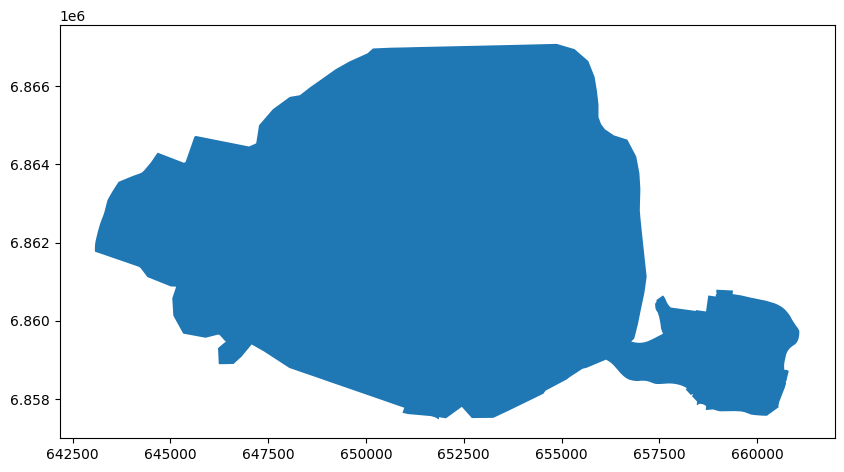

In [53]:
quartier_dissolve = quartier.dissolve()
quartier_dissolve.plot(figsize=(10, 10))

On réalise l'intersection entre les deux :

<Axes: >

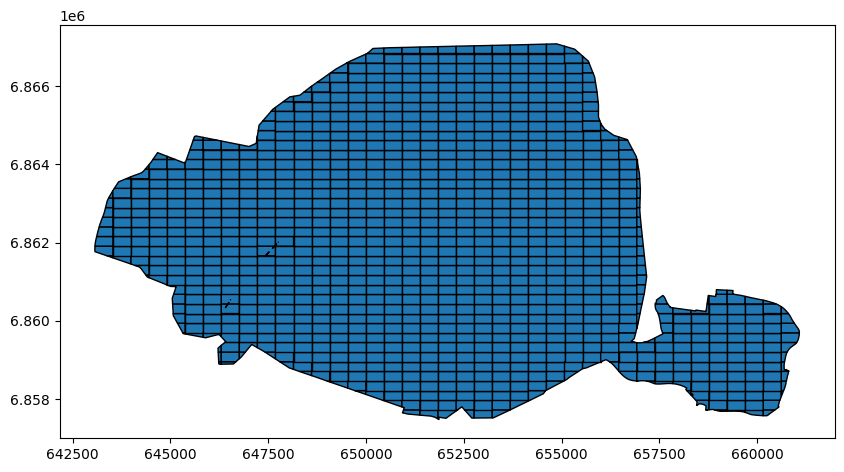

In [64]:
grid_intersection = gpd.overlay(grid, quartier_dissolve, how='intersection')
grid_intersection.plot(figsize=(10, 10), edgecolor='black')

Puis on refait la jointure avec les arbres :

Text(0.5, 1.0, "Nombre d'arbres (rasterisé)")

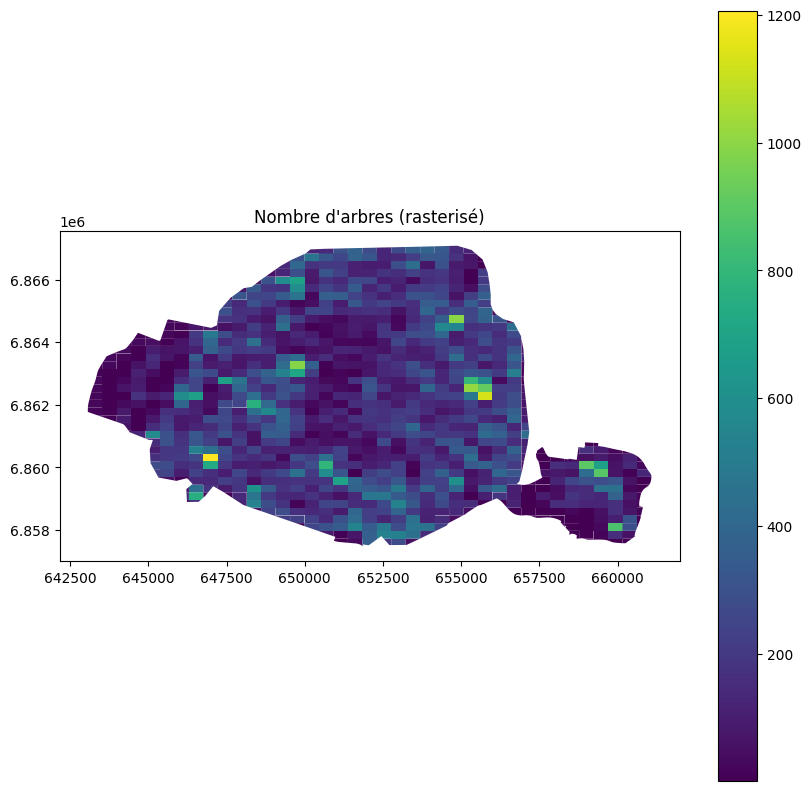

In [66]:
join = grid_intersection.sjoin(
    arbres, how="left", predicate="contains"
    )
grid_intersection["nb_arbres"] = join.index.value_counts()
grid_intersection.plot(figsize=(10, 10), column="nb_arbres", legend=True).set_title("Nombre d'arbres (rasterisé)")

À quoi correspondent les carreaux jaunes ?

##2.3 Cartographie de la densité d’arbres

Text(0.5, 1.0, "Densité d'arbres par quartier")

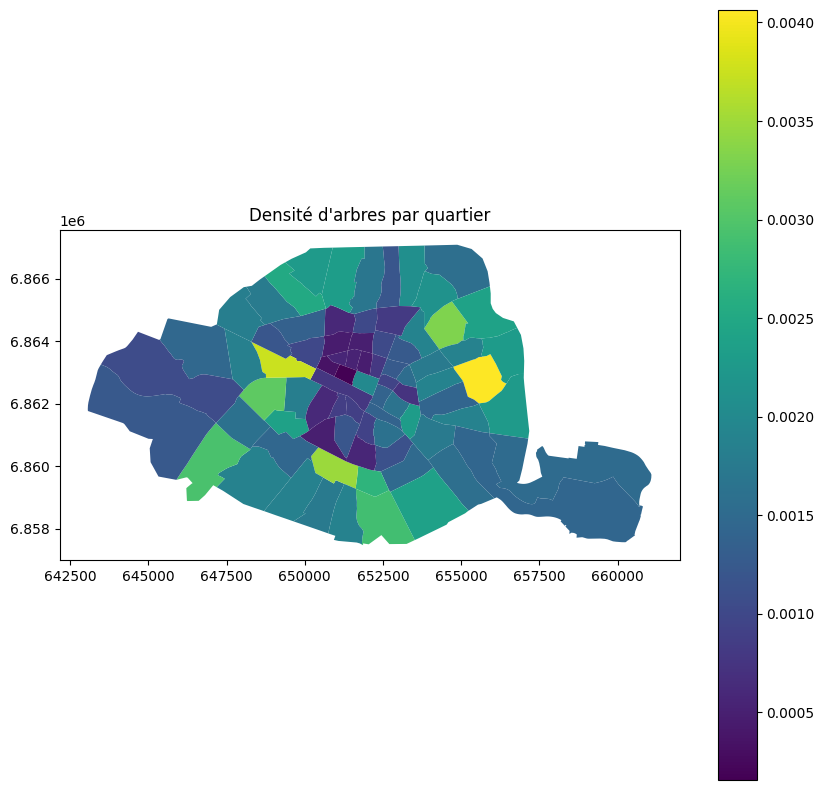

In [49]:
quartier.plot(figsize=(10, 10), column='dens_arbres', legend=True).set_title("Densité d'arbres par quartier")

Connaissant l’implantation des arbres et la formes des quartiers, que dire des densité des quartiers sud-ouest et sud-est ?

Que nous dit la comparaison entre la carte choroplète de nombre et celle de densité ?

Quel est le quartier le plus dense en arbres ?

In [68]:
quartier.sort_values("dens_arbres", ascending=False).head(1)["l_qu"]

,l_qu
n_sq_qu,
750000079.0,PÃ¨re-Lachaise


La densité des bois de Paris ne vous choque pas ? D’où viennent ces faibles densités ? Comment les corriger ?

**Bonus : estimation de densité avec un noyau gaussien**

In [37]:
from scipy.stats import gaussian_kde

x = arbres.geometry.centroid.x
y = arbres.geometry.centroid.y

k = gaussian_kde([x,y])

In [40]:
xi, yi = np.meshgrid(
    np.linspace(x.min(), x.max(), 300),
    np.linspace(y.min(), y.max(), 300)
)
zi = k(np.vstack([
   xi.flatten(),
   yi.flatten()
])).reshape(xi.shape)


<Axes: >

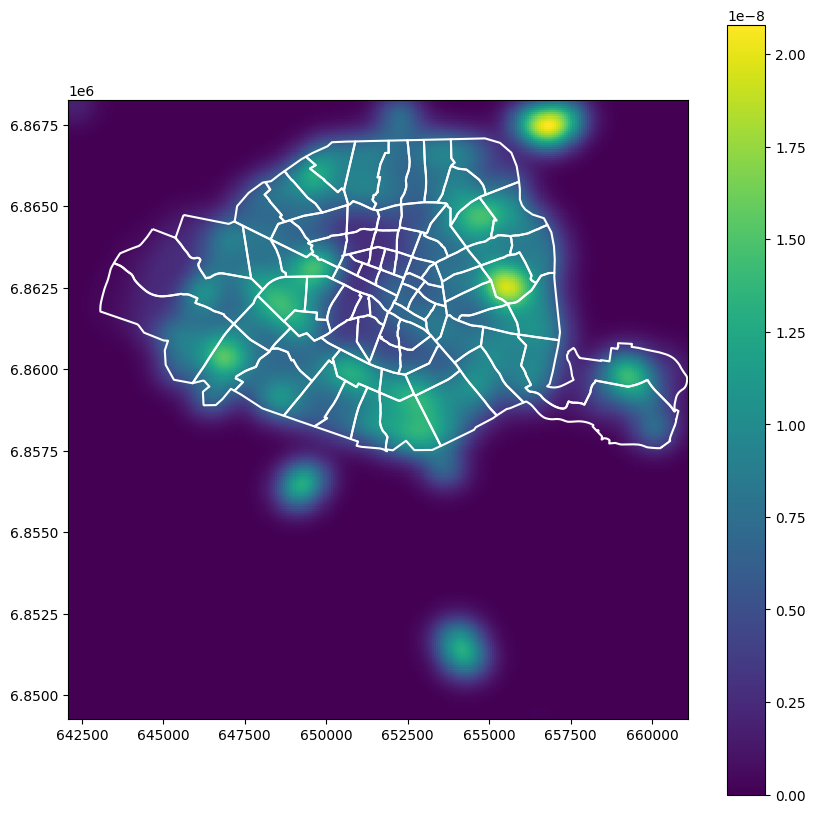

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

plt.pcolormesh(xi, yi, zi)
plt.colorbar()
quartier.boundary.plot(ax=ax, edgecolor='white')

#3 Export des données

In [71]:
arbres.to_file("arbres_paris.gpkg")
quartier.to_file("quartier_paris.gpkg")